M1-M3 are the assumed models. M1-M7 are observation data-generating processes.

## Distance diagnostic

For each assumed model $M_j$, the observation dataset $y$ is first passed through the trained summary network. Let

$$
h_j(y)
$$

denote the summary output for model $M_j$. Using the reference summaries generated under the same assumed model, we compute the Mahalanobis-transformed summary as

$$
z_j(y)
=
L_j^{-1}
\left(
h_j(y) - \mu_j
\right),
$$

where $\mu_j$ is the reference mean summary and $L_j$ is the Cholesky factor of the reference covariance matrix.

The default diagnostic distance is the dimension-normalized Euclidean distance:

$$
d_j(y)
=
\frac{
\left\| z_j(y) \right\|_2
}{
\sqrt{d}
},
$$

where $d$ is the dimension of the summary output. This normalization makes the distance scale less dependent on the summary dimension.

If `distance_metric = "linf"`, we instead use the dimension-normalized $L_\infty$ distance:

$$
d_j(y)
=
\frac{
\left\| z_j(y) \right\|_\infty
}{
\sqrt{2 \log d}
}.
$$

This metric is useful for checking whether one summary coordinate is unusually extreme.

The ambiguity axis is defined as

$$
A(y)
=
\log
\left(
1
+
\frac{1}{
\left| d_{(2)}(y) - d_{(1)}(y) \right|}
\right),
$$

where $d_{(1)}(y)$ and $d_{(2)}(y)$ are the smallest and second-smallest diagnostic distances across the assumed models.

When $A(y)$ is close to $0$, one assumed model is clearly preferred. When $A(y)$ is large, the two closest assumed models have nearly equal diagnostic distances.

In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd

sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 5.0, "mu_prior_std": 0.1, "likelihood_std": 1},

}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [ ]:
# generate test datasets
datasets = {}
for source, spec in source_specs.items():
    data = GetDatasets(
        obs_mu_prior_mean=spec["mu_prior_mean"],
        obs_mu_prior_std=spec["mu_prior_std"],
        num_dims=num_dims,
        num_obs=num_obs,
        obs_likelihood_std=spec["likelihood_std"],
        num_datasets=num_datasets,
        rng=RNG,
    ).get_datasets_normal()
    for item in data:
        item["source_model"] = source
    datasets[source] = data
    save_pickle(data, dataset_dir / f"{source}_raw.pkl") # save datasets seprately for each source model

print(datasets["m1"][0].keys())

In [ ]:
datasets = {source: load_pickle(dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [19]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_40d_100n.keras"
filepath_m2 = network_dir / "m2_s_40d_100n.keras"
filepath_m3 = network_dir / "m3_s_40d_100n.keras"
filepath_m4 = network_dir / "m4_s_40d_100n.keras"
filepath_direct = network_dir / "direct_s_20d_100n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [ ]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [ ]:
# compute logmls and PMPs for all datasets
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

In [23]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
distance_metric = "l2"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,120,0.637028,1.22846,0.845525
m2,l2,120,0.644825,1.241126,0.862877
m3,l2,120,0.666552,1.287388,0.884538
m4,l2,120,0.658124,1.202108,0.863237


In [ ]:
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
logml_df.to_csv(result_dir / "logml_distance_frame.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed.pkl")

# display(logml_summary.round(3))
# display(pmp_summary.round(3))

In [4]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed.pkl") for source in sd.SOURCE_MODELS}
logml_df = pd.read_csv(result_dir / "logml_distance_frame.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame.csv")

## Plots

In [ ]:
# signed logml error with shared y-axis
# sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir,error_bound=1000);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

In [ ]:
# # signed logml error without shared y-axis
# sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir, sharey=False);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir, sharey=False);

In [ ]:
# PMP plots excluding m5 and m4
pmp_no_m5 = pmp_df[pmp_df["source_model"] != "m5"].copy()
pmp_no_m5 = pmp_no_m5[pmp_no_m5["source_model"] != "m4"].copy()

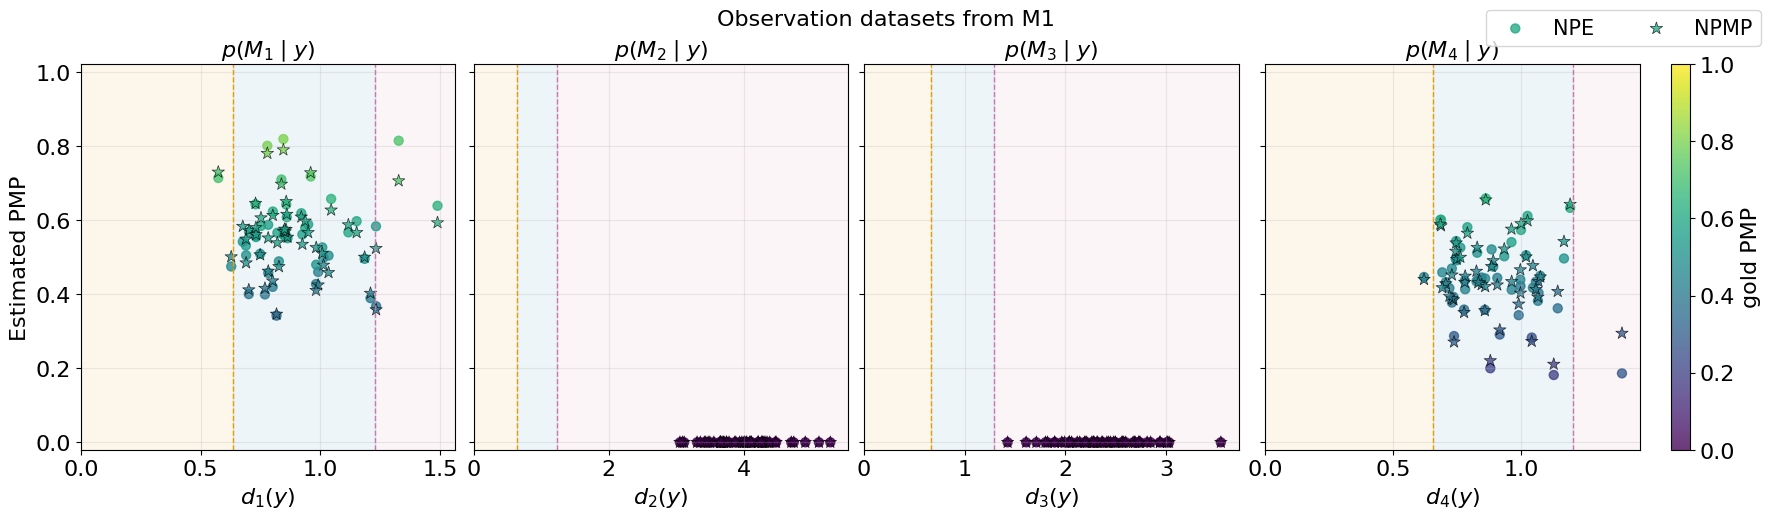

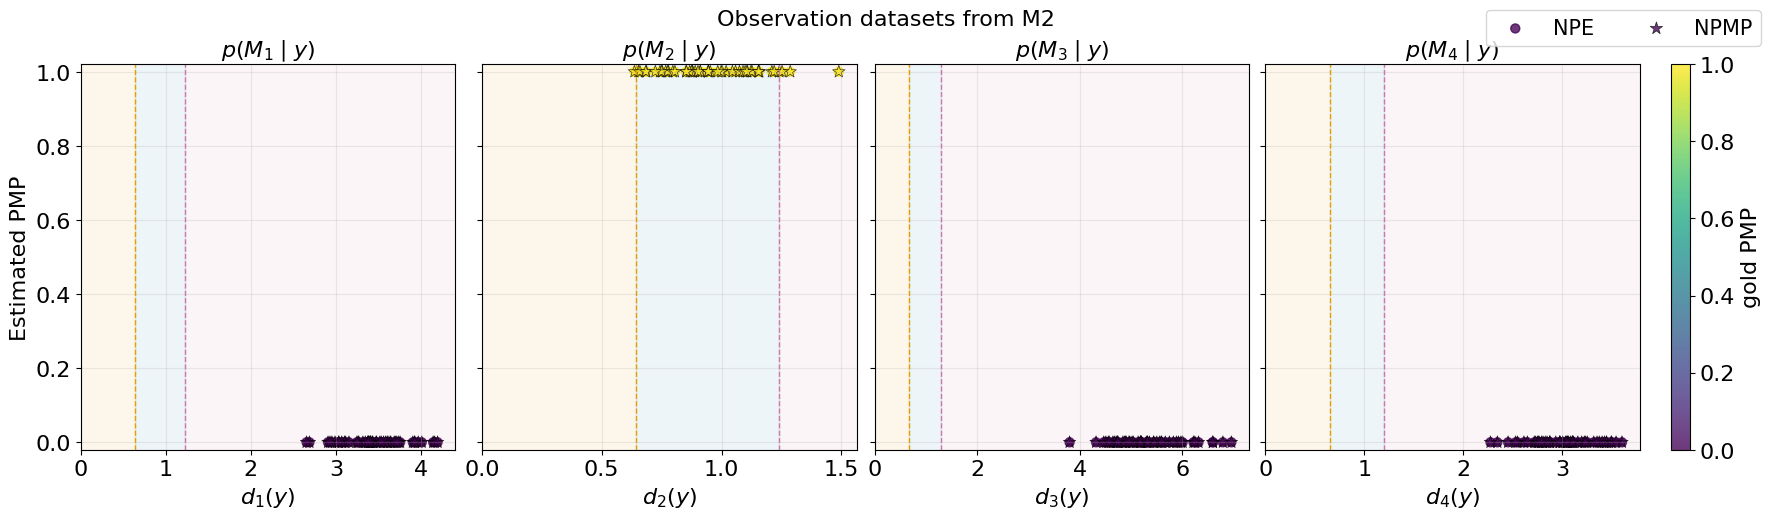

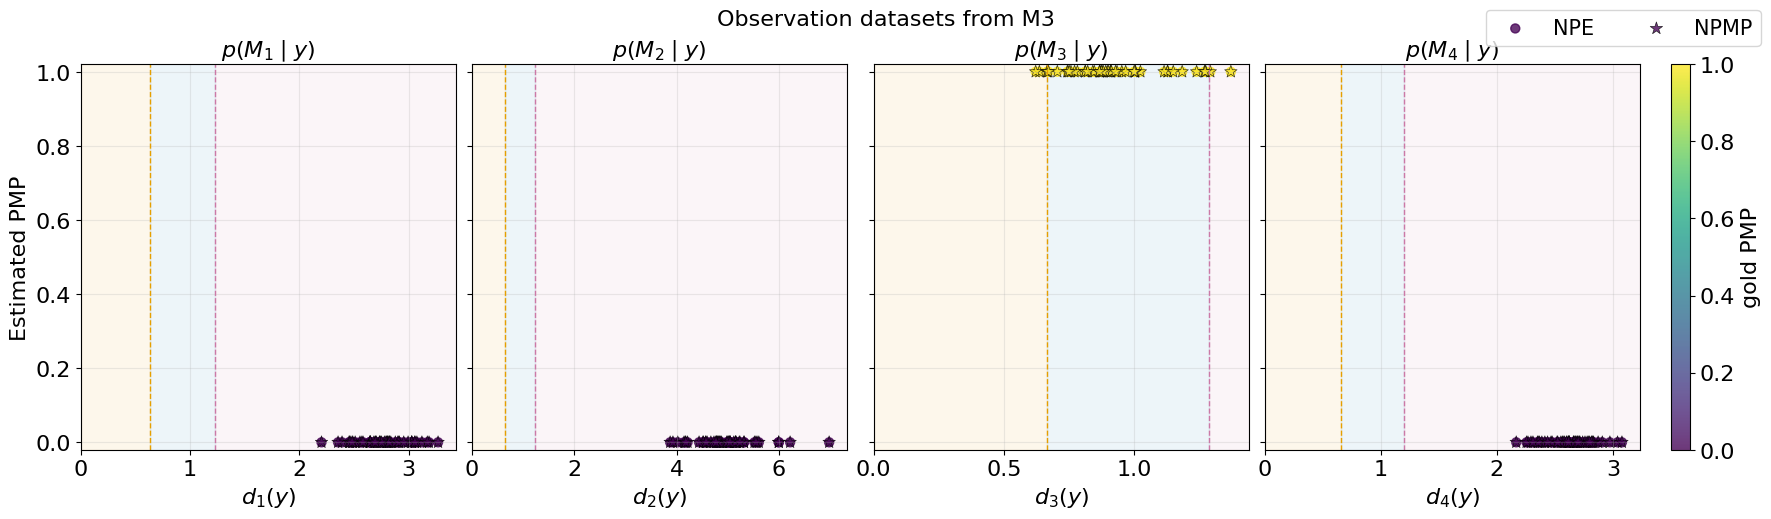

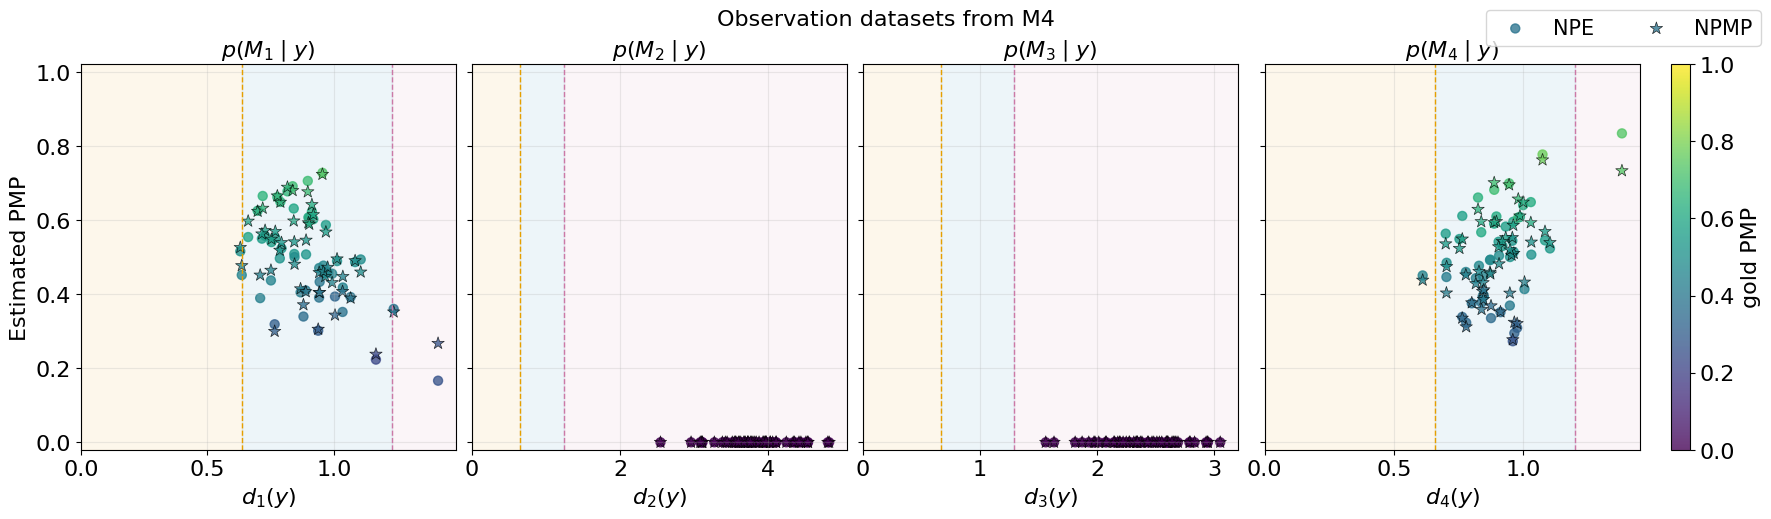

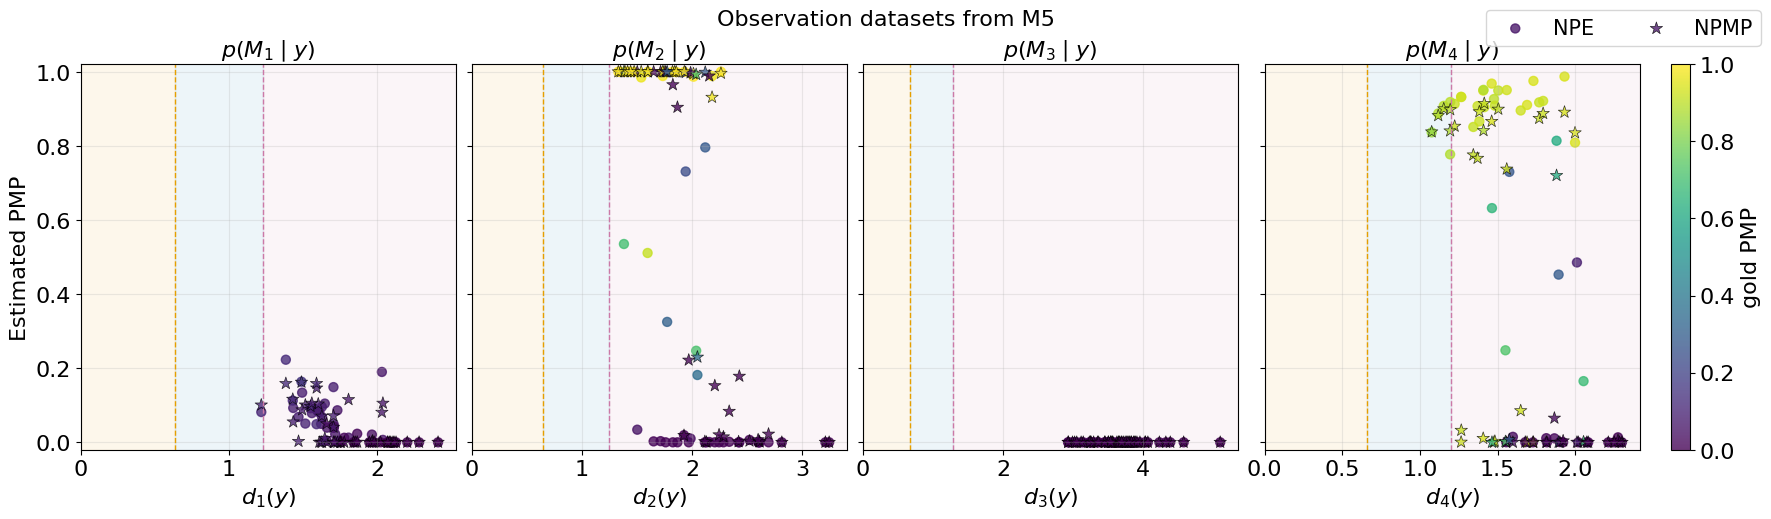

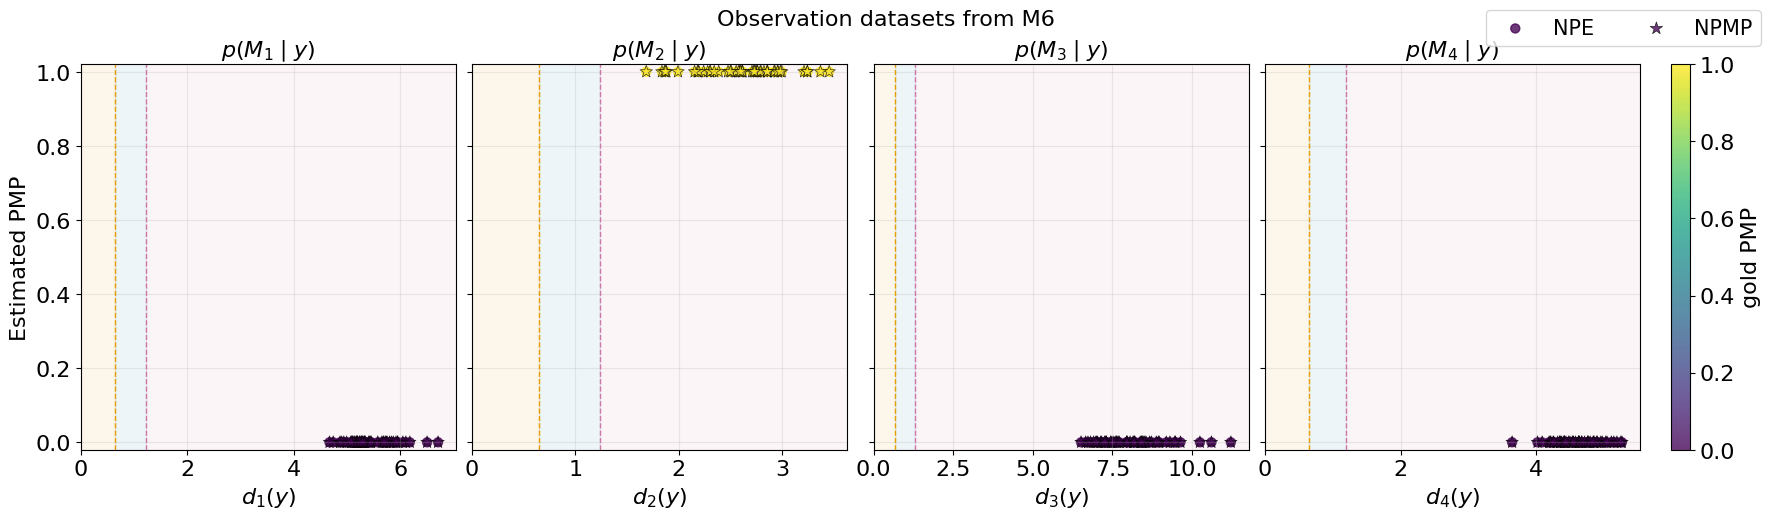

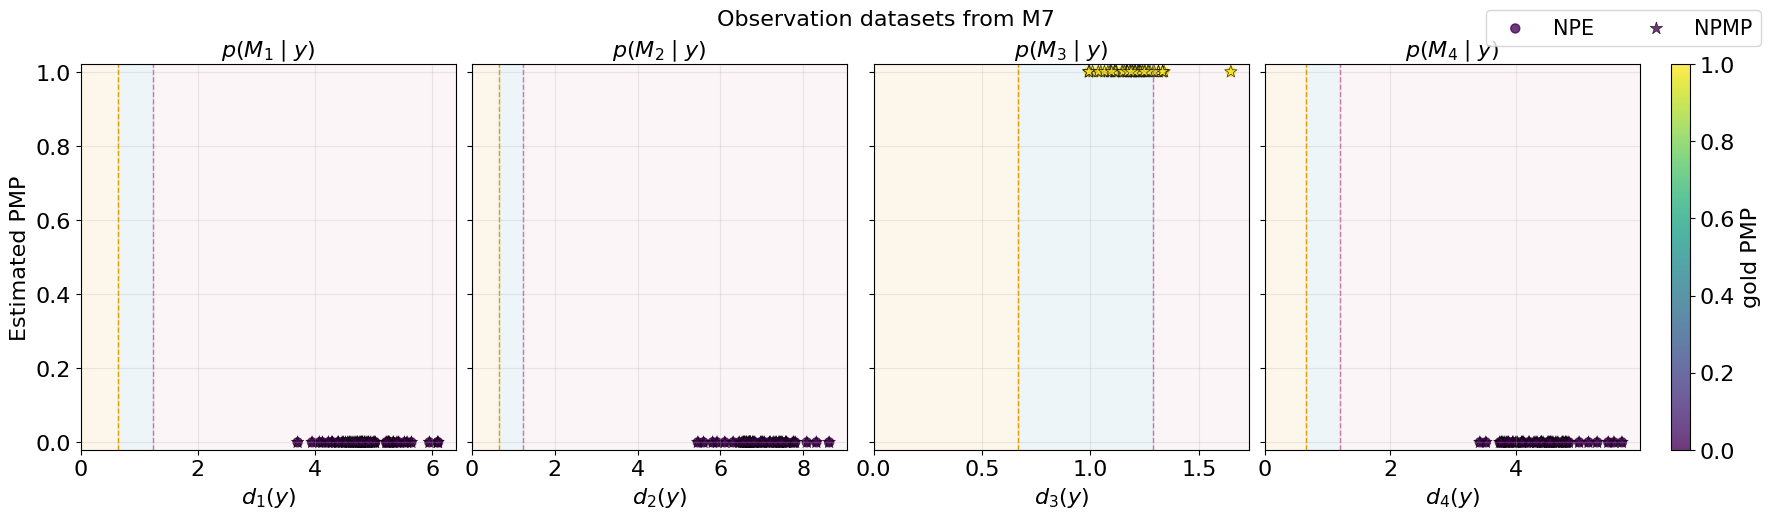

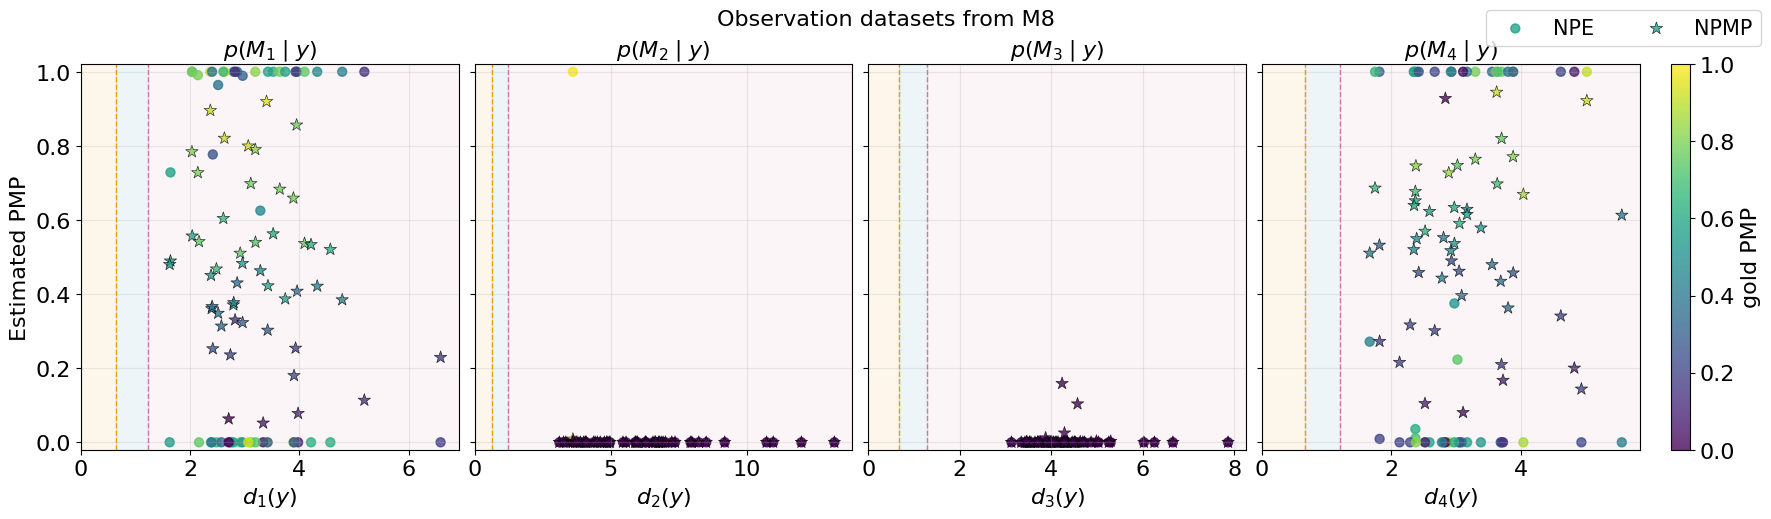

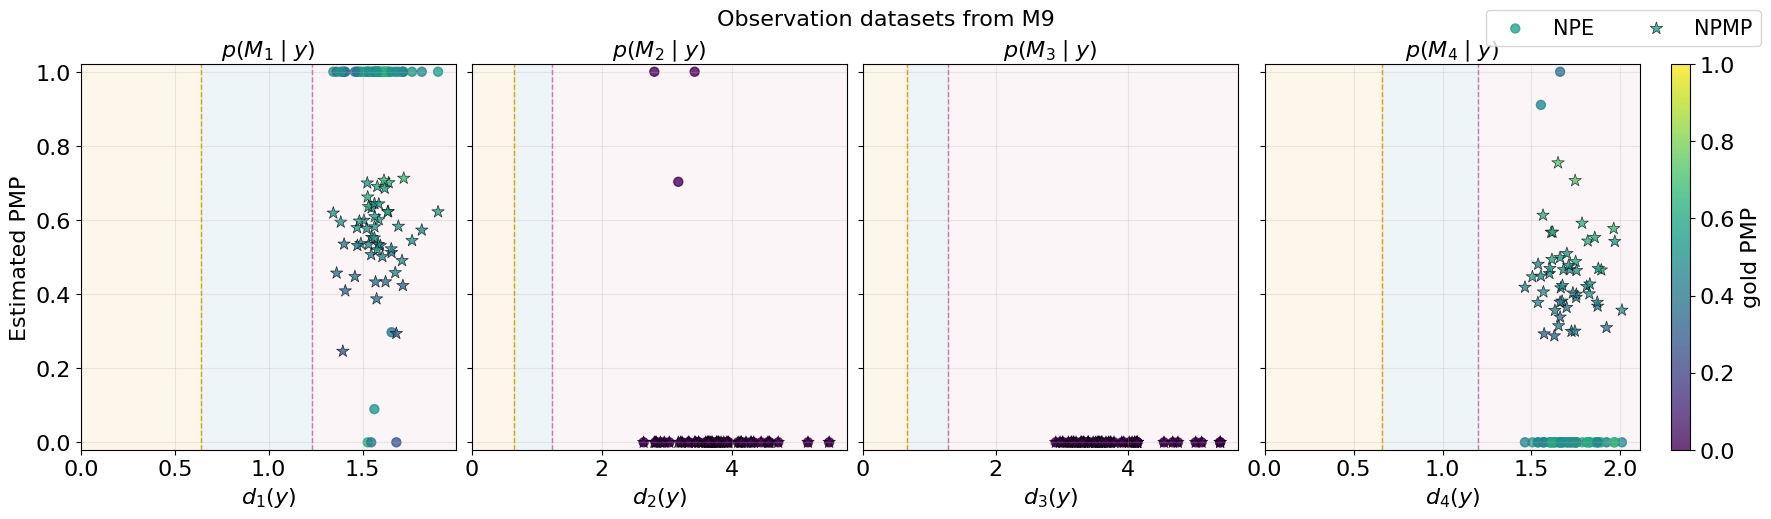

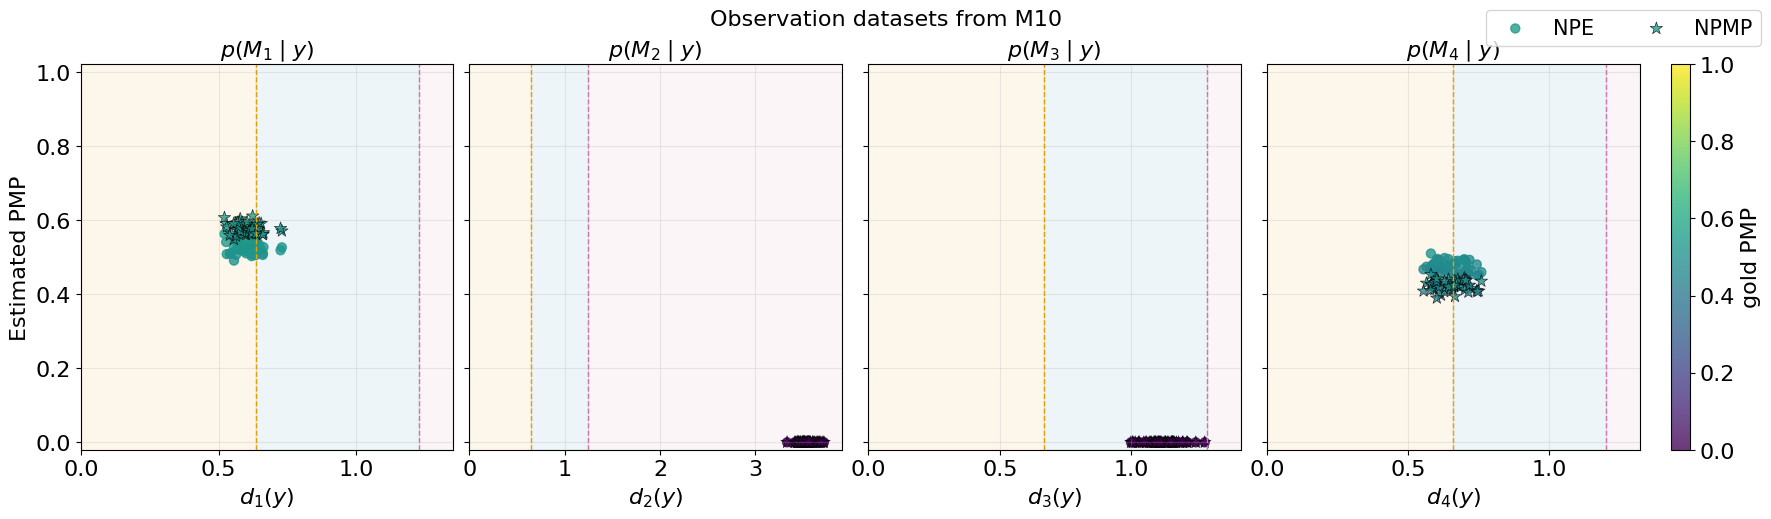

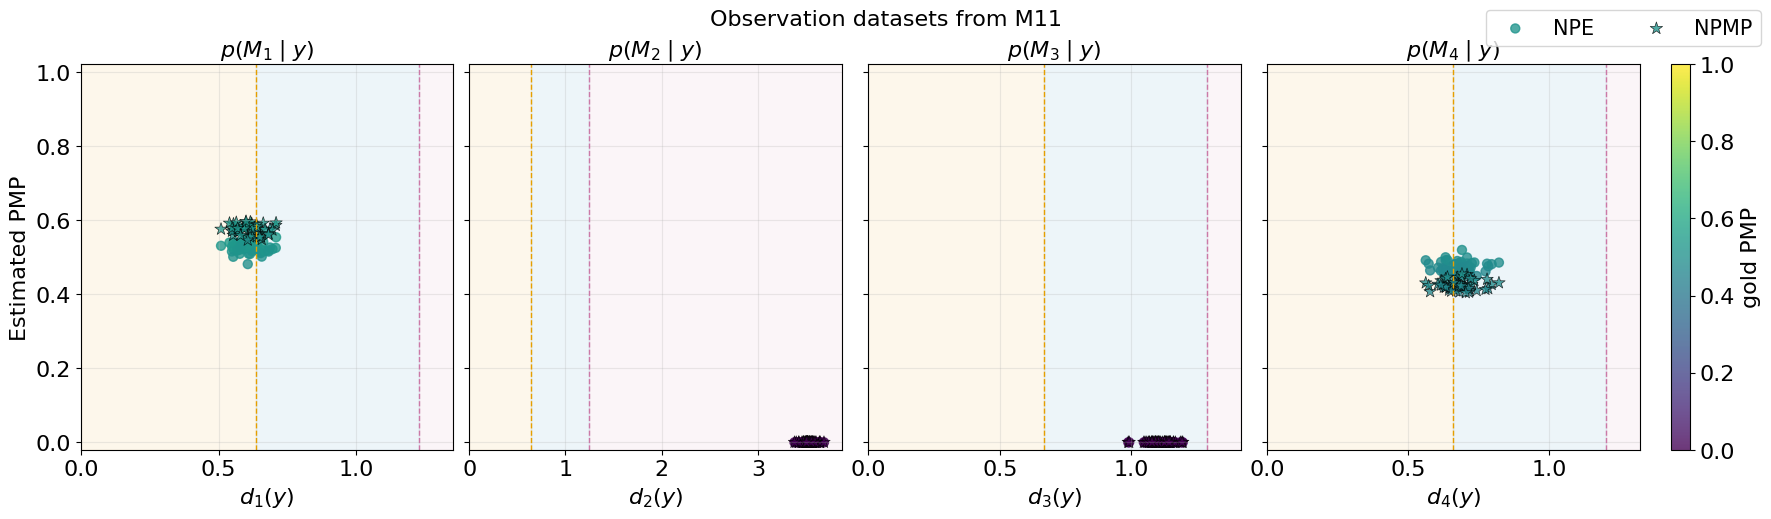

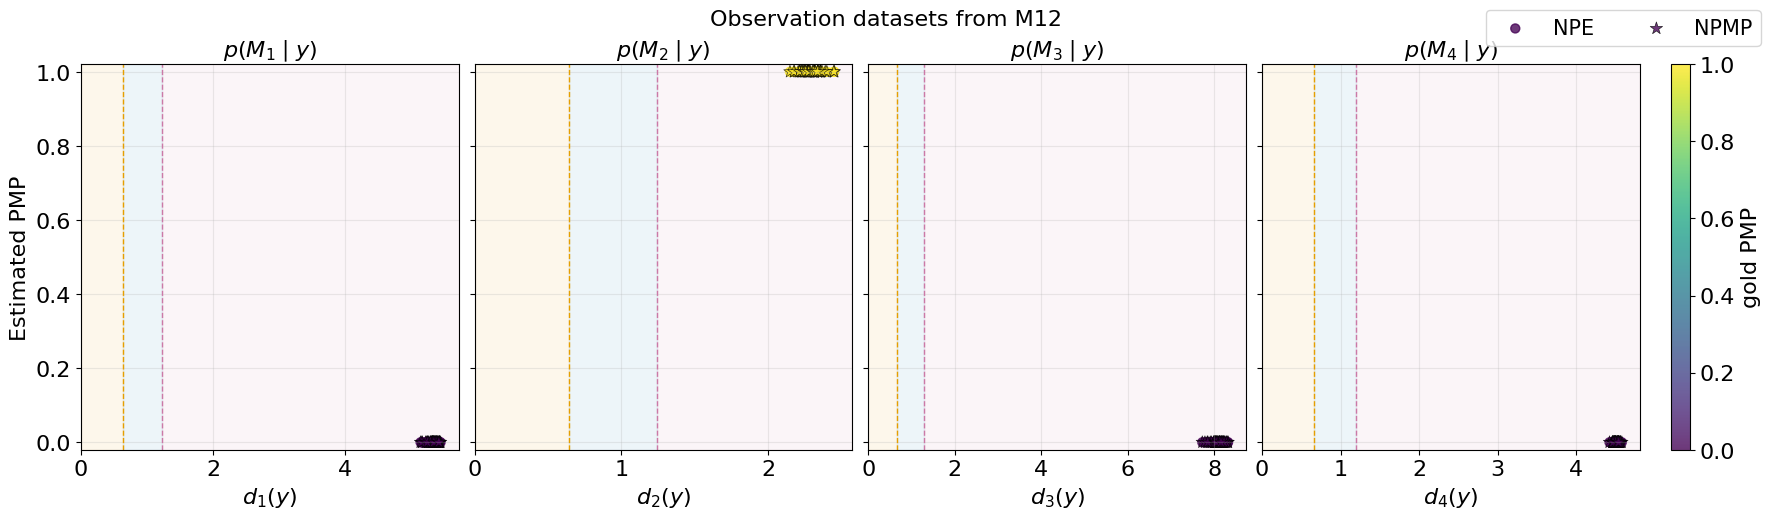

In [15]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

In [20]:
# change to linf distance metric and repeat analysis
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
distance_metric = "linf"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,linf,120,0.544729,1.228564,0.778606
m2,linf,120,0.555604,1.276198,0.788932
m3,linf,120,0.556537,1.301418,0.805192
m4,linf,120,0.566306,1.240573,0.7907


In [21]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed.pkl") for source in sd.SOURCE_MODELS}
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
logml_df.to_csv(result_dir / "logml_distance_frame_linf.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame_linf.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary_linf.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary_linf.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_linf.pkl")

In [ ]:
sd.plot_pmp_diagnostic(pmp_df, x="log_distance", y="signed_error", group_by="global_extrapolation", regions="assumed", estimate="npe", output_dir=figure_dir, filename="pmp_error_vs_distance_npe.png", sharex=True, error_bound=0.1)
sd.plot_pmp_diagnostic(pmp_df, x="log_distance", y="signed_error", group_by="source_model", regions="assumed", estimate="npe", output_dir=figure_dir, filename="pmp_error_vs_distance_npe.png", sharex=True, error_bound=0.1)